In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the MASTER file — not ml_ready — we need post-placement columns here
df = pd.read_csv('Recruitment_master.csv')
print(f"Loaded: {df.shape}")
print(f"client_satisfaction_score nulls: {df['client_satisfaction_score'].isna().sum()}")

Loaded: (500, 49)
client_satisfaction_score nulls: 0


Placed candidates: (370, 49)

client_satisfaction_score distribution:
count    370.000000
mean       6.581081
std        2.436215
min        1.000000
25%        5.000000
50%        7.000000
75%        8.000000
max       10.000000
Name: client_satisfaction_score, dtype: float64


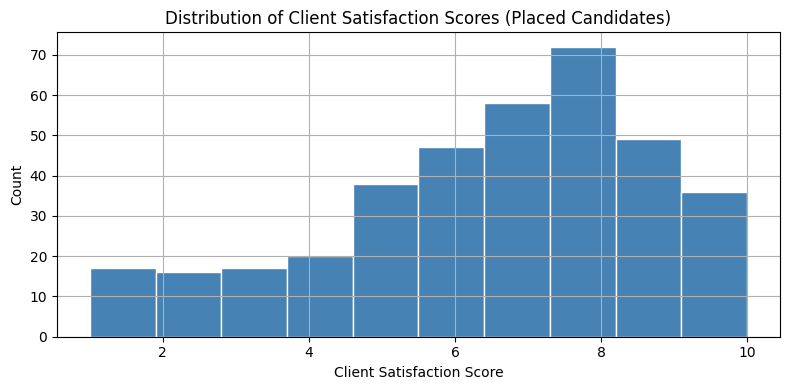

In [12]:
# Only placed candidates have a satisfaction score
df_placed = df[df['was_placed'] == 1].copy()
print(f"Placed candidates: {df_placed.shape}")
print(f"\nclient_satisfaction_score distribution:")
print(df_placed['client_satisfaction_score'].describe())

# Quick visualisation
plt.figure(figsize=(8, 4))
df_placed['client_satisfaction_score'].hist(bins=10, color='steelblue', edgecolor='white')
plt.xlabel('Client Satisfaction Score')
plt.ylabel('Count')
plt.title('Distribution of Client Satisfaction Scores (Placed Candidates)')
plt.tight_layout()
plt.savefig('satisfaction_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Features legitimately available for predicting satisfaction
# These are all things known AT or AFTER placement — all valid for this target
feature_cols = [
    # Candidate pre-placement attributes
    'years_of_experience',
    'expected_salary_gbp',
    'assessment_score',
    'english_proficiency',
    'availability_notice_days',
    'skills_count',
    'days_since_registration',
    'seniority_encoded',
    # Post-placement process features — legitimate here
    'offered_salary_gbp',
    'time_to_hire_days',
    'interview_rounds',
    'salary_gap',
]

# Keep only columns that exist
feature_cols = [c for c in feature_cols if c in df_placed.columns]

# Add encoded categoricals if present
cat_features = [c for c in df_placed.columns if any(
    x in c for x in ['remote_preference', 'source_channel', 'job_function',
                      'seniority_level', 'visa_status', 'nationality']
)]
feature_cols = feature_cols + cat_features[:20]  # limit to avoid noise

target = 'client_satisfaction_score'

# Build X and y
X = df_placed[feature_cols].select_dtypes(include='number')
y = df_placed[target]

print(f"Features: {X.shape[1]}")
print(f"Target range: {y.min():.1f} – {y.max():.1f}")
print(f"Target mean: {y.mean():.2f}")
print(f"Null check — X: {X.isna().sum().sum()} | y: {y.isna().sum()}")

Features: 11
Target range: 1.0 – 10.0
Target mean: 6.58
Null check — X: 0 | y: 0


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (296, 11) | Test: (74, 11)


In [15]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("=== LINEAR REGRESSION ===")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_lr):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.4f}")
print(f"R²:   {r2_score(y_test, y_pred_lr):.4f}")

=== LINEAR REGRESSION ===
MAE:  1.8778
RMSE: 2.2324
R²:   0.1765


In [16]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

print("=== RIDGE REGRESSION ===")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_ridge):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.4f}")
print(f"R²:   {r2_score(y_test, y_pred_ridge):.4f}")

=== RIDGE REGRESSION ===
MAE:  1.8785
RMSE: 2.2326
R²:   0.1764


In [17]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== RANDOM FOREST REGRESSOR ===")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_rf):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.4f}")
print(f"R²:   {r2_score(y_test, y_pred_rf):.4f}")

=== RANDOM FOREST REGRESSOR ===
MAE:  1.8247
RMSE: 2.2192
R²:   0.1863


In [18]:
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("=== GRADIENT BOOSTING REGRESSOR ===")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_gb):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_gb)):.4f}")
print(f"R²:   {r2_score(y_test, y_pred_gb):.4f}")

=== GRADIENT BOOSTING REGRESSOR ===
MAE:  1.8520
RMSE: 2.2657
R²:   0.1518


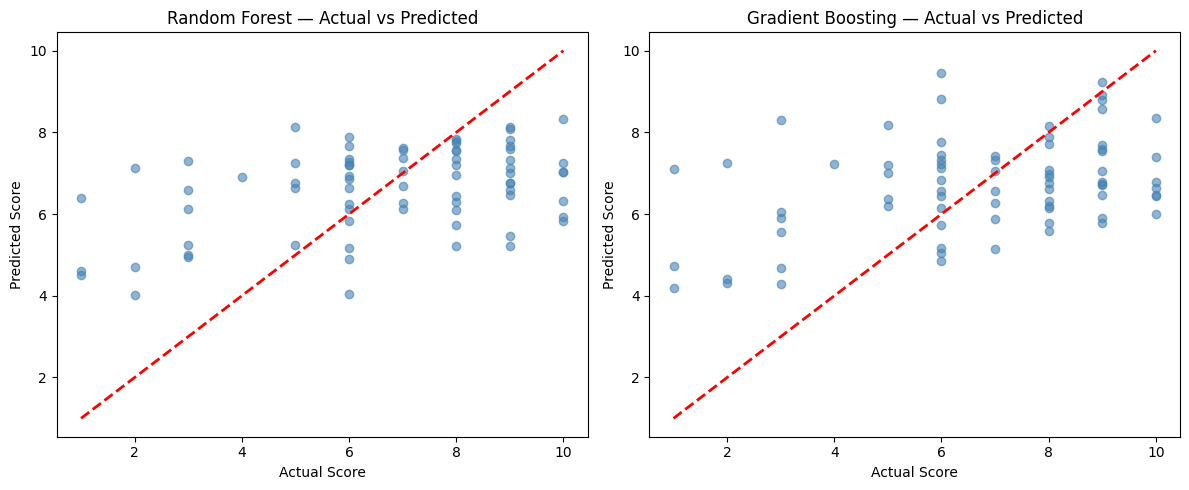

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(axes,
    [y_pred_rf, y_pred_gb],
    ['Random Forest', 'Gradient Boosting']):
    ax.scatter(y_test, preds, alpha=0.6, color='steelblue')
    ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
    ax.set_xlabel('Actual Score')
    ax.set_ylabel('Predicted Score')
    ax.set_title(f'{title} — Actual vs Predicted')

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

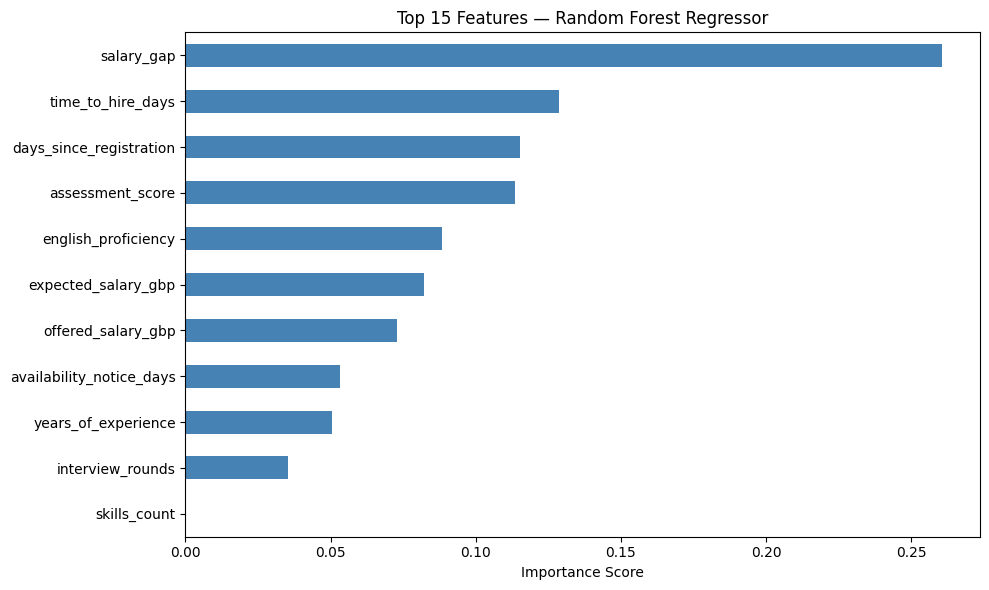

            Model    MAE   RMSE     R²
Linear Regression 1.8778 2.2324 0.1765
            Ridge 1.8785 2.2326 0.1764
    Random Forest 1.8247 2.2192 0.1863
Gradient Boosting 1.8520 2.2657 0.1518

Saved: satisfaction_model_results.csv

5-Fold CV R² Scores: [ 0.2232  0.0475 -0.1131  0.0235  0.159 ]
Mean R²: 0.0680 (+/- 0.1162)


In [20]:
# Feature importance from Random Forest
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
top15 = feat_imp.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top15.sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Importance Score')
plt.title('Top 15 Features — Random Forest Regressor')
plt.tight_layout()
plt.savefig('satisfaction_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Final summary table
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Random Forest', 'Gradient Boosting'],
    'MAE':  [mean_absolute_error(y_test, p) for p in [y_pred_lr, y_pred_ridge, y_pred_rf, y_pred_gb]],
    'RMSE': [np.sqrt(mean_squared_error(y_test, p)) for p in [y_pred_lr, y_pred_ridge, y_pred_rf, y_pred_gb]],
    'R²':   [r2_score(y_test, p) for p in [y_pred_lr, y_pred_ridge, y_pred_rf, y_pred_gb]]
}).round(4)

print(results.to_string(index=False))
results.to_csv('satisfaction_model_results.csv', index=False)
print("\nSaved: satisfaction_model_results.csv")

# Cross-validation on best model
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
print(f"\n5-Fold CV R² Scores: {cv_scores.round(4)}")
print(f"Mean R²: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")